In [1]:
import pandas as pd
from datetime import datetime  # Import datetime
df = r"C:\Users\Admin\Desktop\JMD327_MainProject\JMD327_JElite\DataEngineering\DataEngineering\DataEngineering\curated_schema\curated.csv"
df = pd.read_csv(df)
df.head()

,enrollment_id,employee_id,course_id,enrolled_date,completed_date,progress,ratings,category,course_name,course_duration,...,role_outcome,employee_name,current_role,skills,dateofbirth,dateofjoining,email,mobile_number,Address,yearofexperience
0,1,467,22,2023-08-12,2023-12-04,70,1.5,Neutral,Advanced Data Visualization,2,...,senior data analyst,Amy Marshall,junior data engineer,Data Warehousing,1985-12-03,2019-04-20,dana47@example.com,4628457648,"267 Lisa Mountain, East Andrew, OK 58058",5
1,1,467,22,2023-08-12,2023-12-04,70,1.5,Neutral,Advanced Data Visualization,2,...,senior data analyst,Kevin Cooper,senior data engineer,Hadoop,1986-11-14,2020-04-20,caldwellnancy@example.com,19555605208844,"138 Daniels Via Suite 795, Michaelfurt, MO 20891",4
2,1,467,22,2023-08-12,2023-12-04,70,1.5,Neutral,Advanced Data Visualization,2,...,senior data analyst,Lauren Williams,junior data analyst,Excel,1995-09-01,2005-04-25,garciajonathan@example.net,1460330722535172,"25003 Larson Terrace, Whiteshire, ME 56722",19
3,2,425,15,2024-08-12,2024-10-01,84,5.0,Positive,Introduction to React,3,...,junior software engineer,Sean Smith,senior software engineer,DevOps,1982-08-04,2016-12-26,george12@example.org,38054185195949,"8043 Nicholas Island, Nathanberg, MS 78194",7
4,2,425,15,2024-08-12,2024-10-01,84,5.0,Positive,Introduction to React,3,...,junior software engineer,Stephanie Singh,junior data analyst,Tableau,1969-08-15,2013-07-15,valenciastephanie@example.net,12798403517414,"188 Michael Brook Suite 540, Paynemouth, PW 12845",11


In [2]:
# Drop specified columns from the DataFrame, ignoring any that are not found
df.drop([
    'enrollment_id', 'employee_id', 'course_id', 'enrolled_date', 
    'completed_date', 'progress', 'ratings', 'employee_name', 
    'price', 'course_duration', 'email', 'mobile_number', 
    'Address', 'dateofbirth', 'dateofjoining'
], 
        axis=1, inplace=True, errors='ignore')


# Display the first few rows of the updated DataFrame
df.head()


,category,course_name,outcome_skill,role_outcome,current_role,skills,yearofexperience
0,Neutral,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data engineer,Data Warehousing,5
1,Neutral,Advanced Data Visualization,Predictive Analytics,senior data analyst,senior data engineer,Hadoop,4
2,Neutral,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data analyst,Excel,19
3,Positive,Introduction to React,CSS,junior software engineer,senior software engineer,DevOps,7
4,Positive,Introduction to React,CSS,junior software engineer,junior data analyst,Tableau,11


In [3]:
df.dtypes

category            object
course_name         object
outcome_skill       object
role_outcome        object
current_role        object
skills              object
yearofexperience     int64
dtype: object

In [4]:
df['yearofexperience'].unique()

array([ 5,  4, 19,  7, 11, 15,  3, 17, 16,  0,  9, 10,  8, 13, 18, 14,  2,
        6, 12,  1])

## Feature Engineering

In [5]:
df['feedback_category'] = df['category']
bins = [0, 2, 5, 10, 20, float('inf')]  # Binning intervals
labels = ['0-2', '2-5', '5-10', '10-20', '20+']  # Labels for each bin

# Binning the 'yearofexperience' column into categories
df['yearofexperience_category'] = pd.cut(df['yearofexperience'], bins=bins, labels=labels, right=False)

# Convert the new column to categorical type
df['yearofexperience_category'] = df['yearofexperience_category'].astype('category')
df.head()


,category,course_name,outcome_skill,role_outcome,current_role,skills,yearofexperience,feedback_category,yearofexperience_category
0,Neutral,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data engineer,Data Warehousing,5,Neutral,5-10
1,Neutral,Advanced Data Visualization,Predictive Analytics,senior data analyst,senior data engineer,Hadoop,4,Neutral,2-5
2,Neutral,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data analyst,Excel,19,Neutral,10-20
3,Positive,Introduction to React,CSS,junior software engineer,senior software engineer,DevOps,7,Positive,5-10
4,Positive,Introduction to React,CSS,junior software engineer,junior data analyst,Tableau,11,Positive,10-20


In [6]:
# Converting specific columns to categorical type
df['course_name'] = df['course_name'].astype('category')
df['outcome_skill'] = df['outcome_skill'].astype('category')
df['role_outcome'] = df['role_outcome'].astype('category')
df['current_role'] = df['current_role'].astype('category')
df['skills'] = df['skills'].astype('category')
df['feedback_category'] = df['feedback_category'].astype('category')

# Checking the updated data types
print(df.dtypes)


category                       object
course_name                  category
outcome_skill                category
role_outcome                 category
current_role                 category
skills                       category
yearofexperience                int64
feedback_category            category
yearofexperience_category    category
dtype: object


In [7]:
df.drop(['yearofexperience','category'],axis=1,inplace=True)
df.head()

,course_name,outcome_skill,role_outcome,current_role,skills,feedback_category,yearofexperience_category
0,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data engineer,Data Warehousing,Neutral,5-10
1,Advanced Data Visualization,Predictive Analytics,senior data analyst,senior data engineer,Hadoop,Neutral,2-5
2,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data analyst,Excel,Neutral,10-20
3,Introduction to React,CSS,junior software engineer,senior software engineer,DevOps,Positive,5-10
4,Introduction to React,CSS,junior software engineer,junior data analyst,Tableau,Positive,10-20


In [8]:
unique_count = df['current_role'].nunique()
print(unique_count)


8


In [9]:
df.columns

Index(['course_name', 'outcome_skill', 'role_outcome', 'current_role',
       'skills', 'feedback_category', 'yearofexperience_category'],
      dtype='object')

In [10]:
df.dtypes

course_name                  category
outcome_skill                category
role_outcome                 category
current_role                 category
skills                       category
feedback_category            category
yearofexperience_category    category
dtype: object

In [17]:
display(df)

,course_name,outcome_skill,role_outcome,current_role,skills,feedback_category,yearofexperience_category
0,Advanced Data Visualization,"Data Visualization, Python",senior data scientist,data analyst,"Python, SQL",Positive,5-10
1,Data Modeling,"SQL, Python, Data Modeling",data engineer,junior data engineer,"SQL, Python",Neutral,3-5
2,Machine Learning,"Machine Learning, Python",machine learning engineer,junior ml engineer,"Python, ML",Positive,1-3
3,Deep Learning,"Deep Learning, Neural Networks",deep learning engineer,ai engineer,"AI, Python",Neutral,5-10


In [11]:
df['feedback_category'].head()

0     Neutral
1     Neutral
2     Neutral
3    Positive
4    Positive
Name: feedback_category, dtype: category
Categories (3, object): ['Negative', 'Neutral', 'Positive']

In [12]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
import numpy as np


# Correctly define categorical_columns
categorical_columns = ['course_name', 'outcome_skill', 'role_outcome', 
                       'current_role', 'skills', 'feedback_category', 
                       'yearofexperience_category']

# Preprocess: Convert columns to string and strip whitespace
for column in categorical_columns:
    df[column] = df[column].astype(str).str.strip()  # Convert to string and strip whitespace

# Use OneHotEncoder with handle_unknown='ignore'
encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
encoded_features = encoder.fit_transform(df[categorical_columns]).toarray()

# Fit K-Means Clustering
n_clusters = 24  # Choose the number of clusters based on your data
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(encoded_features)

# Add cluster labels to the original DataFrame
df['cluster'] = kmeans.labels_

# Function to recommend a course based on a new employee's data
def recommend_courses_based_on_role(new_employee_data, encoder, kmeans, df):
    # Clean and prepare the new employee data
    if len(new_employee_data) != len(categorical_columns):
        raise ValueError("New employee data must match the number of categorical columns.")

    # Convert the new employee data to a DataFrame
    new_employee_df = pd.DataFrame([new_employee_data], columns=categorical_columns)

    # Ensure all values are in the expected format (string and stripped)
    for column in categorical_columns:
        new_employee_df[column] = new_employee_df[column].astype(str).str.strip()

    # Get the desired role outcome and current skills
    desired_role_outcome = new_employee_df['role_outcome'].values[0]
    current_role = new_employee_df['current_role'].values[0]
    current_skills = set(new_employee_df['skills'].values[0].split(','))

    # Filter courses based on the desired role outcome and relevant skills
    relevant_courses = df[df['role_outcome'] == desired_role_outcome]

    # Further filter by checking if the skills are related to the courses
    recommended_courses = []
    for _, course in relevant_courses.iterrows():
        course_skills = set(course['outcome_skill'].split(','))
        if not current_skills.intersection(course_skills):  # Recommend if there is no skill match
            recommended_courses.append(course['course_name'])

    return list(set(recommended_courses))  # Return unique course names

# New employee data (example)
new_employee_data = ['Advanced Data Visualization', 'Data Modeling', 
                     'senior data scientist', 'junior software engineer', 
                     'Microservices, Python', 'Neutral', '5-10']

# Get recommended courses
recommended_courses = recommend_courses_based_on_role(new_employee_data, encoder, kmeans, df)
print(f'Recommended Courses: {recommended_courses}')


Recommended Courses: ['AI for Everyone', 'Deep Learning Specialization', 'Advanced Machine Learning']


In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Perform PCA to reduce the dimensionality of the encoded features to 2D
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(encoded_features)

# Create a scatter plot of the 2D PCA-reduced features, colored by cluster labels
plt.figure(figsize=(10, 7))
plt.scatter(
    reduced_features[:, 0],
    reduced_features[:, 1],
    c=kmeans.labels_,
    cmap="viridis",
    s=50,
)
plt.colorbar(label="Cluster Label")

# Plot cluster centers if desired
cluster_centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    cluster_centers[:, 0],
    cluster_centers[:, 1],
    c="red",
    marker="x",
    s=200,
    label="Centroids",
)

# Label the plot
plt.title("K-means Clustering (PCA-reduced data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()


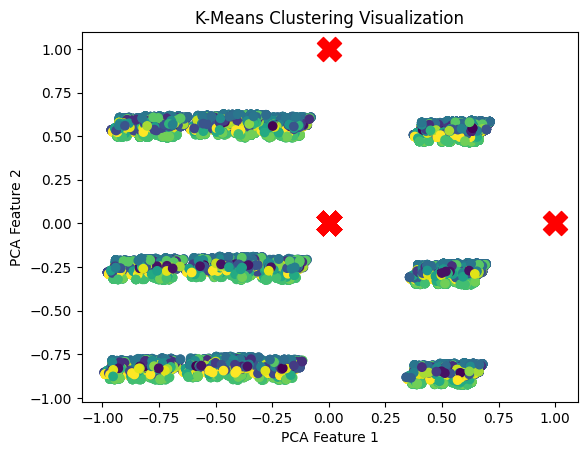

In [18]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reduce dimensionality for visualization
pca = PCA(n_components=2)
pca_features = pca.fit_transform(encoded_features)

# Plot the clusters
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=kmeans.labels_, cmap="viridis")
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
)
plt.title("K-Means Clustering Visualization")
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.show()


In [14]:
import joblib

# Save the OneHotEncoder
encoder_filename = "onehot_encoder.joblib"
joblib.dump(encoder, encoder_filename)

# Save the KMeans model
kmeans_filename = "kmeans_model.joblib"
joblib.dump(kmeans, kmeans_filename)

print(f"Models saved: {encoder_filename} and {kmeans_filename}")


Models saved: onehot_encoder.joblib and kmeans_model.joblib


In [15]:
df.head()

,course_name,outcome_skill,role_outcome,current_role,skills,feedback_category,yearofexperience_category,cluster
0,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data engineer,Data Warehousing,Neutral,5-10,19
1,Advanced Data Visualization,Predictive Analytics,senior data analyst,senior data engineer,Hadoop,Neutral,2-5,19
2,Advanced Data Visualization,Predictive Analytics,senior data analyst,junior data analyst,Excel,Neutral,10-20,19
3,Introduction to React,CSS,junior software engineer,senior software engineer,DevOps,Positive,5-10,0
4,Introduction to React,CSS,junior software engineer,junior data analyst,Tableau,Positive,10-20,0


In [16]:
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import joblib
import pandas as pd

# Load the previously saved models
encoder = joblib.load("onehot_encoder.joblib")
kmeans = joblib.load("kmeans_model.joblib")

# Sample DataFrame structure (used for recommendations)
# In real implementation, you'd load or query a database for this
df = pd.DataFrame(
    {
        "course_name": [
            "Advanced Data Visualization",
            "Data Modeling",
            "Machine Learning",
            "Deep Learning",
        ],
        "outcome_skill": [
            "Data Visualization, Python",
            "SQL, Python, Data Modeling",
            "Machine Learning, Python",
            "Deep Learning, Neural Networks",
        ],
        "role_outcome": [
            "senior data scientist",
            "data engineer",
            "machine learning engineer",
            "deep learning engineer",
        ],
        "current_role": [
            "data analyst",
            "junior data engineer",
            "junior ml engineer",
            "ai engineer",
        ],
        "skills": ["Python, SQL", "SQL, Python", "Python, ML", "AI, Python"],
        "feedback_category": ["Positive", "Neutral", "Positive", "Neutral"],
        "yearofexperience_category": ["5-10", "3-5", "1-3", "5-10"],
    }
)


# Define the structure of input data using Pydantic
class EmployeeData(BaseModel):
    course_name: str
    outcome_skill: str
    role_outcome: str
    current_role: str
    skills: str
    feedback_category: str
    yearofexperience_category: str


# Initialize the FastAPI app
app = FastAPI()


# Define the recommendation function
def recommend_courses_based_on_role(new_employee_data, encoder, kmeans, df):
    # Ensure all values are in the expected format (string and stripped)
    new_employee_df = pd.DataFrame([new_employee_data.dict()])

    # Get the desired role outcome and current skills
    desired_role_outcome = new_employee_df["role_outcome"].values[0]
    current_skills = set(new_employee_df["skills"].values[0].split(","))

    # Filter courses based on the desired role outcome and relevant skills
    relevant_courses = df[df["role_outcome"] == desired_role_outcome]

    # Further filter by checking if the skills are related to the courses
    recommended_courses = []
    for _, course in relevant_courses.iterrows():
        course_skills = set(course["outcome_skill"].split(","))
        if not current_skills.intersection(
            course_skills
        ):  # Recommend if there is no skill match
            recommended_courses.append(course["course_name"])

    return list(set(recommended_courses))  # Return unique course names


# Define a POST route to get the recommendations
@app.post("/recommend")
def recommend_courses(employee_data: EmployeeData):
    try:
        # Use the recommendation function
        recommended_courses = recommend_courses_based_on_role(
            employee_data, encoder, kmeans, df
        )

        # Return the response as JSON
        return {"recommended_courses": recommended_courses}
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))


# Run the app using Uvicorn
# Command: uvicorn script_name:app --reload
